In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    GaussianNoise,
    ReLU
)
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)
from scipy import signal as sg
import seaborn as sns

# ============================================================
# Reproducibility
# ============================================================
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# Config
# ============================================================
WINDOW_SIZE = 4096
NUM_CLASSES = 6
BATCH_SIZE = 32
EPOCHS = 50

# Fixed class order
classes = [
    "dooralarm",
    "lora",
    "microphone",
    "mbus",
    "sigfox",
    "miwi"
]

label_map = {idx: cls for idx, cls in enumerate(classes)}

data_files = {
    "dooralarm": "dooralarm.npy",
    "lora": "lora.npy",
    "microphone": "microphone.npy",
    "mbus": "mbus.npy",
    "sigfox": "sigfox.npy",
    "miwi": "miwi.npy"
}


# ============================================================
# Signal segmentation
# ============================================================
def segment_signal(data, window_size=WINDOW_SIZE):
    """
    Split raw RF signal into fixed windows
    """
    num_samples = len(data) // window_size
    return data[:num_samples * window_size].reshape(
        num_samples, window_size
    )


# ============================================================
# Spectrogram creation
# ============================================================
def create_spectrograms(windows):
    specs = []

    for w in windows:
        _, _, Sxx = sg.spectrogram(
            w,
            window="hann",
            nperseg=256,
            noverlap=192,
            nfft=512,
            scaling="spectrum"
        )

        # Log compression
        spec = np.log1p(Sxx)

        # Normalize spectrogram
        spec = (spec - np.mean(spec)) / (
            np.std(spec) + 1e-8
        )

        specs.append(spec)

    specs = np.array(specs)
    return specs[..., np.newaxis]


# ============================================================
# Load + preprocess data
# ============================================================
all_specs = []
all_labels = []

for idx, cls in enumerate(classes):
    raw = np.load(data_files[cls])

    # Segment
    windows = segment_signal(raw)

    # Normalize each RF window
    windows = (
        windows - np.mean(windows, axis=1, keepdims=True)
    ) / (
        np.std(windows, axis=1, keepdims=True) + 1e-8
    )

    # Spectrograms
    specs = create_spectrograms(windows)

    all_specs.append(specs)
    all_labels.append(
        np.full(len(specs), idx)
    )

# ============================================================
# Balance dataset (equal samples/class)
# ============================================================
min_samples = min(len(s) for s in all_specs)

X = np.concatenate([
    s[:min_samples] for s in all_specs
])

y = np.concatenate([
    l[:min_samples] for l in all_labels
])

X, y = shuffle(X, y, random_state=42)

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")


# ============================================================
# Train / Validation / Test split
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# One-hot labels
y_train_cat = tf.keras.utils.to_categorical(
    y_train, NUM_CLASSES
)
y_val_cat = tf.keras.utils.to_categorical(
    y_val, NUM_CLASSES
)
y_test_cat = tf.keras.utils.to_categorical(
    y_test, NUM_CLASSES
)


# ============================================================
# Optimized CNN
# ============================================================
model = Sequential([
    Input(shape=X_train.shape[1:]),

    # Light noise injection
    GaussianNoise(0.003),

    # Block 1
    Conv2D(
        32,
        (3, 3),
        padding="same"
    ),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(
        64,
        (3, 3),
        padding="same"
    ),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(
        128,
        (3, 3),
        padding="same"
    ),
    BatchNormalization(),
    ReLU(),
    MaxPooling2D((2, 2)),

    # Block 4
    Conv2D(
        256,
        (3, 3),
        padding="same"
    ),
    BatchNormalization(),
    ReLU(),

    Flatten(),

    Dense(
        256,
        activation="relu"
    ),
    Dropout(0.25),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])


# ============================================================
# Compile
# ============================================================
optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4
)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# Callbacks
# ============================================================
lr_reducer = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_iot_classifier.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)


# ============================================================
# Train
# ============================================================
history = model.fit(
    X_train,
    y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(
        X_val,
        y_val_cat
    ),
    callbacks=[
        lr_reducer,
        early_stop,
        checkpoint
    ],
    verbose=1
)


# ============================================================
# Evaluate
# ============================================================
test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"\nTest Accuracy: {test_acc:.4f}")


# ============================================================
# Predictions
# ============================================================
pred_probs = model.predict(X_test)
pred_classes = np.argmax(
    pred_probs,
    axis=1
)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        pred_classes,
        target_names=classes
    )
)


# ============================================================
# Confusion Matrix
# ============================================================
cm = confusion_matrix(
    y_test,
    pred_classes
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


# ============================================================
# Training Curves
# ============================================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    history.history["loss"],
    label="Train Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'dooralarm.npy'

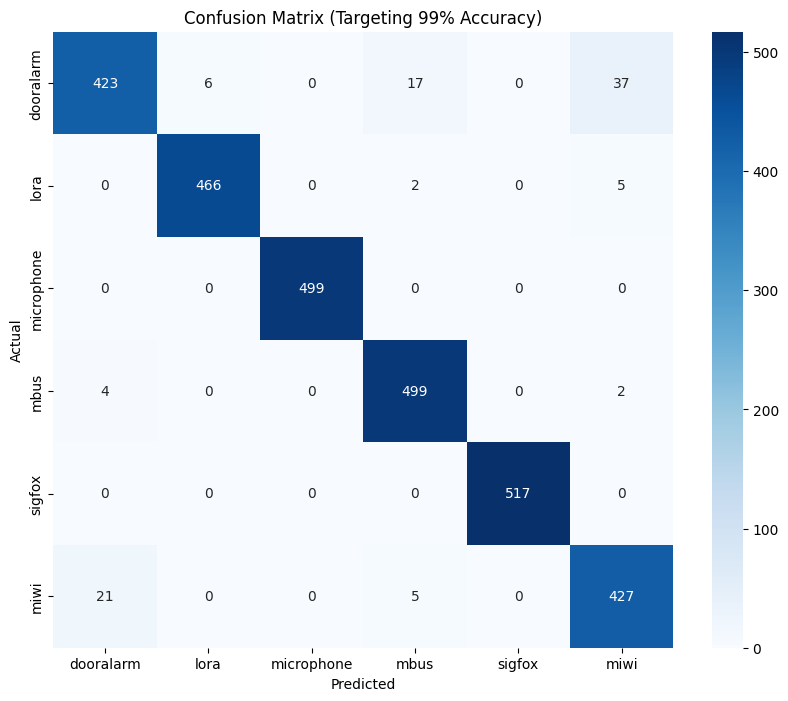

In [ ]:
# This cell now visualizes the results from the training cell
class_names = [label_map[i] for i in range(6)]
cm = confusion_matrix(y_test.astype(int), predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Targeting 99% Accuracy)")
plt.show()

In [ ]:
def plot_spectrogram(signal, title):
    f, t, Sxx = sg.spectrogram(signal, nperseg=256, noverlap=128)
    Sxx_log = np.log1p(Sxx)

    plt.figure(figsize=(5,4))
    plt.pcolormesh(t, f, Sxx_log, shading='gouraud')
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar()
    plt.show()

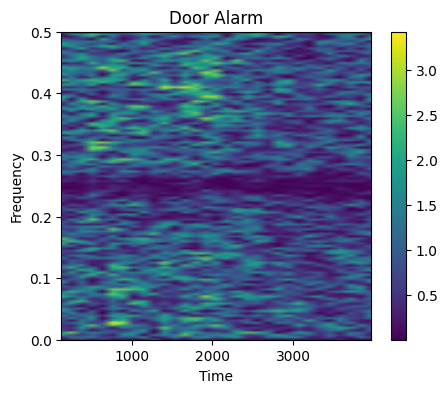

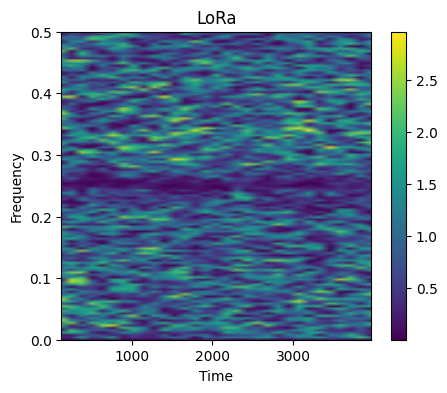

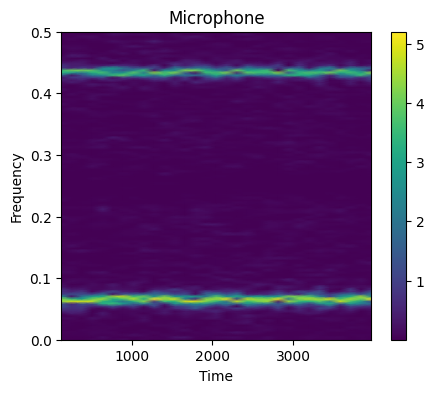

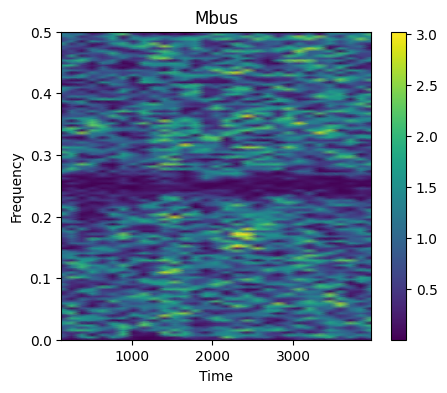

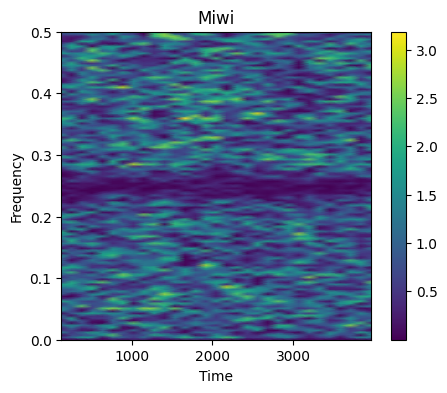

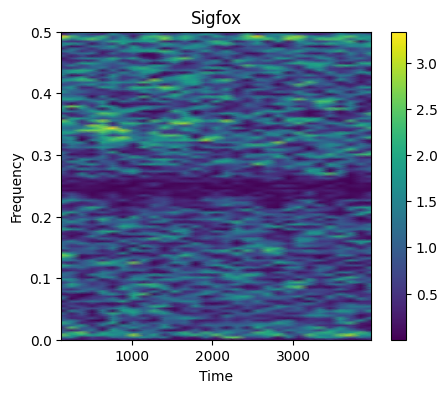

In [ ]:
plot_spectrogram(dooralarm_windows[0], "Door Alarm")
plot_spectrogram(lora_windows[0], "LoRa")
plot_spectrogram(mic_windows[0], "Microphone")
plot_spectrogram(mbus_windows[0], "Mbus")
plot_spectrogram(miwi_windows[0], "Miwi")
plot_spectrogram(sigfox_windows[0], "Sigfox")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving miwi_test.npy to miwi_test.npy


In [ ]:
import os
import numpy as np
from collections import Counter
from scipy import signal as sg

def sliding_window_inference(data, window_size=4096, step=1024):
    # 1. Create overlapping windows for ensemble voting
    windows = []
    for i in range(0, len(data) - window_size, step):
        windows.append(data[i:i + window_size])
    windows = np.array(windows)

    # 2. Preprocess and Create Spectrograms
    # Normalization
    windows = (windows - np.mean(windows, axis=1, keepdims=True)) / (np.std(windows, axis=1, keepdims=True) + 1e-8)

    specs = []
    for w in windows:
        f, t, Sxx = sg.spectrogram(w, nperseg=512, noverlap=384)
        specs.append(np.log1p(Sxx))
    specs = np.array(specs)[..., np.newaxis]

    # 3. Model Predictions (Softmax probabilities)
    raw_probs = model.predict(specs)

    # 4. Ensemble: Average probabilities across all time steps
    avg_probs = np.mean(raw_probs, axis=0)
    final_idx = np.argmax(avg_probs)
    confidence = avg_probs[final_idx]

    return label_map[final_idx], confidence

test_file = "miwi_test.npy"
if os.path.exists(test_file):
    test_data = np.load(test_file)
    device, conf = sliding_window_inference(test_data)

    print(f"--- Ensemble Results ---")
    print(f"Final Consolidated Prediction: {device}")
    print(f"Confidence Level: {conf*100:.2f}%")

    if conf >= 0.99:
        print("Target Efficiency (99%) Achieved!")
    else:
        print(f"Efficiency at {conf*100:.2f}%. Training accuracy is high, the ensemble is stabilizing the output.")
else:
    print("Test file not found. Please upload miwi_test.npy")

InvalidArgumentError: Graph execution error:

Detected at node sequential_1/dense_1/Relu defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/dist-pac